In [4]:
df = load_dataset("cogatlas")
print(df.columns)
print(df.head())

Index(['term', 'definition', 'alias'], dtype='object')
                  term                                         definition  \
0  abductive reasoning  The process of adopting an explanatory hypothe...   
1     abstract analogy  High-level analogy that retains general inform...   
2   abstract knowledge  Knowledge that is general and not tied to a sp...   
3      acoustic coding  A type of short term memory coding that repres...   
4    acoustic encoding  The processing and encoding of auditory input ...   

  alias  
0  None  
1  None  
2  None  
3  None  
4  None  



Available Du Networks:

- VIS-P
- CG-OP
- DN-B
- SMOT-B
- AUD
- PM-PPr
- dATN-B
- SMOT-A
- LANG
- FPN-B
- FPN-A
- dATN-A
- VIS-C
- SAL/PMN
- DN-A
- NONE


/var/folders/7w/n8_hbb5j3dg0gtc5cwfcdqf80000gn/T/ipykernel_59174/3712096384.py:41: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  img_resampled = resample_img(img, masker.mask_img.affine)



Top 10 Cognitive Atlas Concepts for AUD:

1 auditory stream segregation
2 auditory encoding
3 music cognition
4 acoustic phonetic processing
5 auditory tone detection
6 auditory perception
7 acoustic encoding
8 music syntax
9 auditory attention
10 speech processing


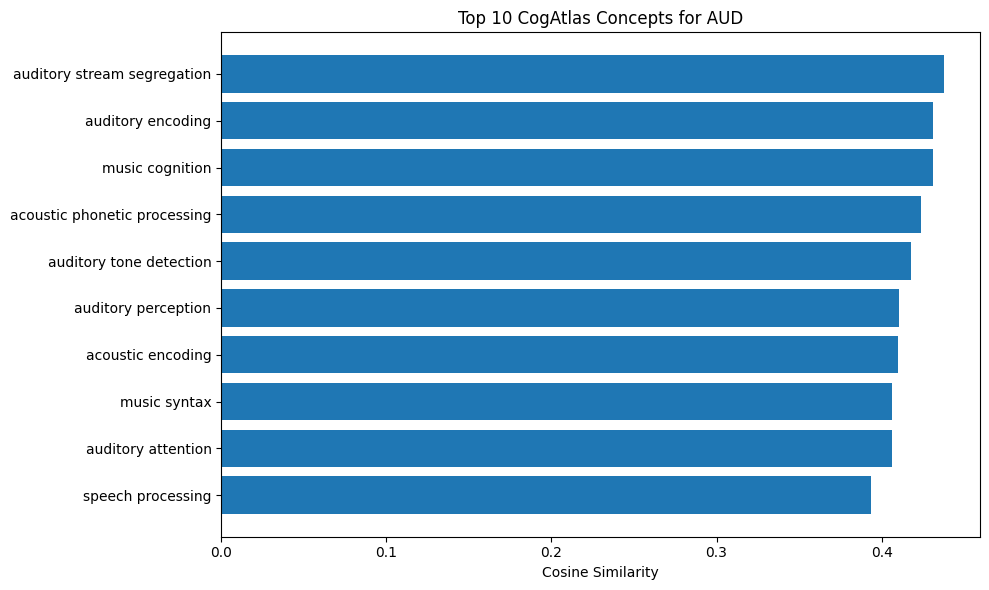

In [2]:
#COGATLAS CONCEPTS

import torch
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.image import resample_img
from neurovlm.data import load_dataset, load_masker, load_latent
from neurovlm.models import load_model
from neurovlm.train import which_device

device = which_device()
device = "cpu"

networks = load_dataset("networks")

print("\nAvailable Du Networks:\n")
for net in networks["Du"].keys():
    print("-", net)

choice = input("\nEnter network name: ").strip()

if choice not in networks["Du"]:
    raise ValueError("Network not found.")

arr = networks["Du"][choice]["array"] > 0

img = nib.Nifti1Image(
    arr.astype(float),
    affine=networks["Du"][choice]["affine"]
)

autoencoder = load_model("autoencoder").to(device)
proj_head_text = load_model("proj_head_text_infonce").to(device)
proj_head_img = load_model("proj_head_image_infonce").to(device)

masker = load_masker()

img_resampled = resample_img(img, masker.mask_img.affine)

img_tensor = torch.from_numpy(
    masker.transform(img_resampled)
)

img_latent = autoencoder.encoder(img_tensor).cpu()

# Loading the CogAtlas Concepts 

latent_text, concept_terms = load_latent("cogatlas")
df = load_dataset("cogatlas")

latent_df = pd.DataFrame({
    "term": concept_terms
})

df = df.merge(latent_df, on="term", how="inner")

latent_text = latent_text[
    [list(concept_terms).index(t) for t in df["term"]]
]

latent_text = latent_text / latent_text.norm(dim=1)[:, None]

latent_text_aligned = proj_head_text(latent_text)
img_latent_aligned = proj_head_img(img_latent)

img_latent_aligned = img_latent_aligned / img_latent_aligned.norm()
latent_text_aligned = latent_text_aligned / latent_text_aligned.norm(dim=1)[:, None]

# Cosine Similarity

cos_sim = (img_latent_aligned @ latent_text_aligned.T).squeeze()
inds = torch.argsort(cos_sim, descending=True)

# Output of top 10 concepts
top_k = 10
top_inds = inds[:top_k].cpu().numpy()
top_scores = cos_sim[top_inds].detach().numpy()
top_concepts = df.iloc[top_inds]["term"]

print(f"\nTop {top_k} Cognitive Atlas Concepts for {choice}:\n")

for i, concept in enumerate(top_concepts, 1):
    print(i, concept)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_concepts, top_scores)
plt.gca().invert_yaxis()
plt.xlabel("Cosine Similarity")
plt.title(f"Top {top_k} CogAtlas Concepts for {choice}")
plt.tight_layout()
plt.show()